# Atividade de vendas no Brasil
## Entregável 1 NumPy
## Entregável 2 Pandas
## Entregável 3 Seaborn

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

caminho_arquivo = '../../data/vendas_brasil_1.csv'
df = pd.read_csv(caminho_arquivo, encoding='latin1')
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,EletrÃ´nicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,VestuÃ¡rio,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,GoiÃ¢nia,App Mobile,VestuÃ¡rio,TÃªnis,JoÃ£o Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,VestuÃ¡rio,CalÃ§a Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,JoÃ£o Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [24]:
preco_unitario = df['preco_unitario'].to_numpy()
custo_unitario = df['custo_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
desconto = df['desconto_pct'].to_numpy() / 100 
frete = df['frete'].to_numpy()
print(preco_unitario[:5])

[739.39 187.48  76.11 145.86 133.92]


In [25]:
valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto * desconto
custo_total = (custo_unitario * quantidade) + frete
lucro_estimado = (valor_bruto - valor_desconto) - custo_total
print(np.round(lucro_estimado[:5], 2))

[1383.24  256.03  190.5   600.51  -22.33]


In [26]:
receita = valor_bruto - valor_desconto
media_receita = np.nanmean(receita)
mascara_acima_media = receita > media_receita
mascara_prejuizo = lucro_estimado < 0
mascara_desconto_alto = desconto > 0.20
print(f"Total de vendas acima da média: {np.sum(mascara_acima_media)}")
print(f"Total de vendas com prejuízo: {np.sum(mascara_prejuizo)}")
print(f"Total de vendas com desconto alto: {np.sum(mascara_desconto_alto)}")

Total de vendas acima da média: 9207
Total de vendas com prejuízo: 7588
Total de vendas com desconto alto: 7037


In [27]:
receita_media = np.nanmean(receita)
maior_receita = np.nanmax(receita)
menor_receita = np.nanmin(receita)
lucro_medio = np.nanmean(lucro_estimado)
qtd_prejuizo = np.sum(mascara_prejuizo)
print(f"1. Receita Média: R$ {receita_media:.2f}")
print(f"2. Maior Receita: R$ {maior_receita:.2f}")
print(f"3. Menor Receita: R$ {menor_receita:.2f}")
print(f"4. Lucro Médio: R$ {lucro_medio:.2f}")
print(f"5. Quantidade de vendas com prejuízo: {qtd_prejuizo}")

1. Receita Média: R$ 1720.53
2. Maior Receita: R$ 51376.47
3. Menor Receita: R$ 3.71
4. Lucro Médio: R$ 313.64
5. Quantidade de vendas com prejuízo: 7588


É possível notar que existe um volume considerável de vendas dando prejuízo, o que puxa o lucro médio para baixo

In [23]:
display(df.head())
df.info()
display(df.describe()) 
print(df.shape) 
print(df.isna().sum())

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,receita_liquida,faixa_receita
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,2022,6572.93904,Alta
1,2023-12-03,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,0.00,4.98,19.0,True,False,False,False,2023,924.69832,Padrão
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,TÃªnis,JoÃ£o Vieira,Bronze,76.11,61.40,...,7.98,3.47,10.0,True,True,False,False,2022,1051.09050,Padrão
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,CalÃ§a Jeans,Carla Mendes,Bronze,145.86,88.53,...,20.49,4.50,16.0,False,True,False,False,2022,1582.87542,Padrão
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,JoÃ£o Vieira,Bronze,133.92,107.25,...,22.89,3.49,13.0,False,True,False,False,2022,86.65020,Padrão


<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data_venda          37617 non-null  datetime64[us]
 1   mes                 37617 non-null  int64         
 2   cidade              37617 non-null  str           
 3   canal_venda         37617 non-null  str           
 4   categoria           37617 non-null  str           
 5   produto             37617 non-null  str           
 6   vendedor            37617 non-null  str           
 7   fidelidade_cliente  37617 non-null  str           
 8   preco_unitario      37617 non-null  float64       
 9   custo_unitario      37617 non-null  float64       
 10  margem_pct          37617 non-null  float64       
 11  quantidade          37617 non-null  int64         
 12  desconto_pct        37617 non-null  float64       
 13  receita_total       37617 non-null  float64       
 14  f

,data_venda,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,ano_venda,receita_liquida
count,37617,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000,37617.000000
mean,2023-01-02 18:29:36.026796,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,28.392920,3.919785,10.016429,2022.505490,1729.537069
min,2022-01-01 00:00:00,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,0.000000,1.000000,1.000000,2022.000000,2.741700
25%,2022-07-03 00:00:00,4.000000,68.960000,49.550000,16.390000,4.000000,0.300000,364.280000,10.930000,3.510000,5.000000,2022.000000,323.150000
50%,2023-01-04 00:00:00,7.000000,111.300000,80.990000,22.714776,7.000000,9.000000,789.570000,20.960000,4.010000,10.000000,2023.000000,713.315790
75%,2023-07-07 00:00:00,9.000000,257.680000,186.570000,29.240000,11.000000,19.000000,1853.210000,38.240000,4.510000,15.000000,2023.000000,1691.668080
max,2023-12-31 00:00:00,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000,2023.000000,49373.586600
std,NaN,3.439296,316.742367,231.376757,8.660758,4.322273,9.097484,2972.445759,25.001269,0.895277,5.366868,0.499977,2769.938559


(37617, 24)
data_venda            0
mes                   0
cidade                0
canal_venda           0
categoria             0
produto               0
vendedor              0
fidelidade_cliente    0
preco_unitario        0
custo_unitario        0
margem_pct            0
quantidade            0
desconto_pct          0
receita_total         0
frete                 0
avaliacao_cliente     0
prazo_entrega_dias    0
devolucao             0
entrega_no_prazo      0
alta_temporada        0
flag_outlier_preco    0
ano_venda             0
receita_liquida       0
faixa_receita         0
dtype: int64


1 quantas linhas e colunas existem? o dataset possui 37617 linhas e 21 colunas
2 existem dados faltantes? sim, temos dados nulos nas colunas `canal_venda`, `vendedor`, `margem_pct`, `frete`, `avaliacao_cliente` e `prazo_entrega_dias`.
3 quais colunas parecem numéricas? `mes`, `preco_unitario`, `custo_unitario`, `margem_pct`, `quantidade`, `desconto_pct`, `receita_total`, `frete`, `avaliacao_cliente` e `prazo_entrega_dias`.
4 Quais colunas parecem categóricas ou de texto?`data_venda`, `cidade`, `canal_venda`, `categoria`, `produto`, `vendedor`, `fidelidade_cliente`, `devolucao`, `entrega_no_prazo` e outras de v ou f

In [28]:
df['data_venda'] = pd.to_datetime(df['data_venda'], dayfirst=True, format='mixed')
df['categoria'] = df['categoria'].str.replace('EletrÃ´nicos', 'Eletrônicos', regex=False)
df['categoria'] = df['categoria'].str.replace('VestuÃ¡rio', 'Vestuário', regex=False)
df['canal_venda'] = df['canal_venda'].str.strip()
df['canal_venda'] = df['canal_venda'].fillna('Desconhecido')
df['vendedor'] = df['vendedor'].fillna('Desconhecido')
df['frete'] = df['frete'].fillna(0)
df['avaliacao_cliente'] = df['avaliacao_cliente'].fillna(df['avaliacao_cliente'].median())
df['prazo_entrega_dias'] = df['prazo_entrega_dias'].fillna(df['prazo_entrega_dias'].median())
df['margem_pct'] = df['margem_pct'].fillna(df['margem_pct'].mean())
display(df[['data_venda', 'categoria', 'frete']].head())

,data_venda,categoria,frete
0,2022-04-13,Eletrônicos,8.68
1,2023-12-03,Vestuário,0.00
2,2022-09-28,Vestuário,7.98
3,2022-04-17,Vestuário,20.49
4,2022-03-13,Esportes,22.89


In [29]:
df['ano_venda'] = df['data_venda'].dt.year
df['receita_liquida'] = df['receita_total'] * (1 - (df['desconto_pct'] / 100))
df['faixa_receita'] = df['receita_liquida'].apply(lambda x: 'Alta' if x > 2000 else 'Padrão')
display(df[['data_venda', 'ano_venda', 'receita_total', 'receita_liquida', 'faixa_receita']].head())

,data_venda,ano_venda,receita_total,receita_liquida,faixa_receita
0,2022-04-13,2022,6933.48,6572.93904,Alta
1,2023-12-03,2023,930.28,924.69832,Padrão
2,2022-09-28,2022,1058.50,1051.09050,Padrão
3,2022-04-17,2022,1592.43,1582.87542,Padrão
4,2022-03-13,2022,107.64,86.65020,Padrão


In [22]:
filtro_receita_alta = df[df['receita_liquida'] > 5000]
filtro_devolucao = df[df['devolucao'] == True]
filtro_eletronicos = df[df['categoria'] == 'Eletrônicos']
print(f"1. Vendas com receita > R$ 5.000: {len(filtro_receita_alta)} registros encontrados.")
print(f"2. Vendas com devolução: {len(filtro_devolucao)} registros encontrados.")
print(f"3. Vendas da categoria Eletrônicos: {len(filtro_eletronicos)} registros encontrados.")
display(filtro_devolucao[['data_venda', 'categoria', 'receita_liquida', 'devolucao']].head())

1. Vendas com receita > R$ 5.000: 3580 registros encontrados.
2. Vendas com devolução: 3532 registros encontrados.
3. Vendas da categoria Eletrônicos: 7515 registros encontrados.


,data_venda,categoria,receita_liquida,devolucao
1,2023-12-03,Vestuário,924.69832,True
2,2022-09-28,Vestuário,1051.09050,True
7,2023-07-09,Alimentação,155.05425,True
18,2023-10-24,Vestuário,264.76000,True
21,2023-07-05,Eletrônicos,6553.00965,True


In [21]:

df['categoria'] = df['categoria'].str.replace('AlimentaÃ§Ã£o', 'Alimentação', regex=False)
df['cidade'] = df['cidade'].str.replace('SÃ£o Paulo', 'São Paulo', regex=False)
df['cidade'] = df['cidade'].str.replace('GoiÃ¢nia', 'Goiânia', regex=False)
receita_categoria = df.groupby('categoria')['receita_liquida'].sum().sort_values(ascending=False)
display(receita_categoria.head())
vendas_canal = df.groupby('canal_venda').size().sort_values(ascending=False)
display(vendas_canal.head())
receita_cidade = df.groupby('cidade')['receita_liquida'].sum().sort_values(ascending=False)
display(receita_cidade.head())
dados_regioes = {
    'cidade': ['Rio de Janeiro', 'São Paulo', 'Belo Horizonte', 'Salvador', 'Fortaleza', 'Recife', 'Manaus', 'Goiânia', 'Porto Alegre', 'Curitiba'],
    'regiao': ['Sudeste', 'Sudeste', 'Sudeste', 'Nordeste', 'Nordeste', 'Nordeste', 'Norte', 'Centro-Oeste', 'Sul', 'Sul']
}
df_regioes = pd.DataFrame(dados_regioes)
df_merged = pd.merge(df, df_regioes, on='cidade', how='left')
receita_regiao = df_merged.groupby('regiao')['receita_liquida'].sum().sort_values(ascending=False)
display(receita_regiao)

categoria
Eletrônicos    4.114391e+07
Esportes       1.058481e+07
Vestuário      6.202034e+06
Livros         4.085464e+06
Alimentação    3.043774e+06
Name: receita_liquida, dtype: float64

canal_venda
Site Web        11267
App Mobile      11168
Loja FÃ­sica     7445
Marketplace      5604
Televendas       1861
dtype: int64

cidade
Recife          7.019926e+06
Manaus          6.786452e+06
Fortaleza       6.612910e+06
Goiânia         6.523309e+06
Porto Alegre    6.404825e+06
Name: receita_liquida, dtype: float64

regiao
Nordeste        1.987535e+07
Sudeste         1.871060e+07
Sul             1.269994e+07
Norte           6.786452e+06
Centro-Oeste    6.523309e+06
Name: receita_liquida, dtype: float64

O agrupamento de dados mostrou logo de cara os pontos fortes da operação,a categoria e a cidade que mais dão retorno financeiro, além do canal de vendas mais usado. Depois disso, cruzar os dados (`merge`) com a tabela auxiliar foi essencial para termos uma visão mais ampla e entender como o faturamento está distribuído pelas regiões do Brasil.

Entregável 3 Seaborn


C:\Users\Maximino\AppData\Local\Temp\ipykernel_25524\4011312292.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receita_cat, x='categoria', y='receita_liquida', palette='Blues_r')


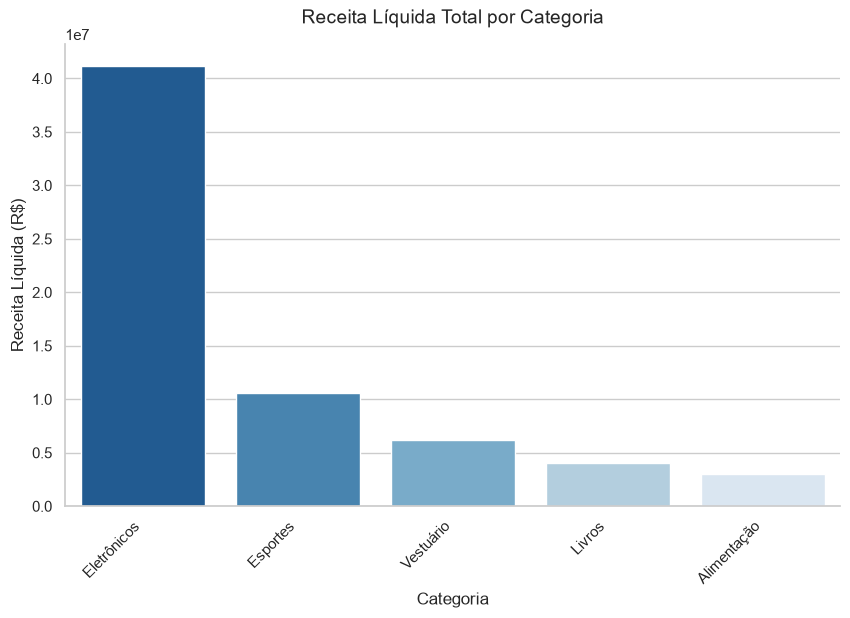

In [30]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
receita_cat = df.groupby('categoria')['receita_liquida'].sum().reset_index()
receita_cat = receita_cat.sort_values(by='receita_liquida', ascending=False)
sns.barplot(data=receita_cat, x='categoria', y='receita_liquida', palette='Blues_r')
plt.title('Receita Líquida Total por Categoria', fontsize=14, pad=15)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Receita Líquida (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.show()

O gráfico deixa claro que a categoria de eletrônicos é o principal gerador de receita empresa, gerando um volume de receita líquida muito superior em relação as outras categorias, enquanto livros e alimentação tem impacto fraco no faturamento.

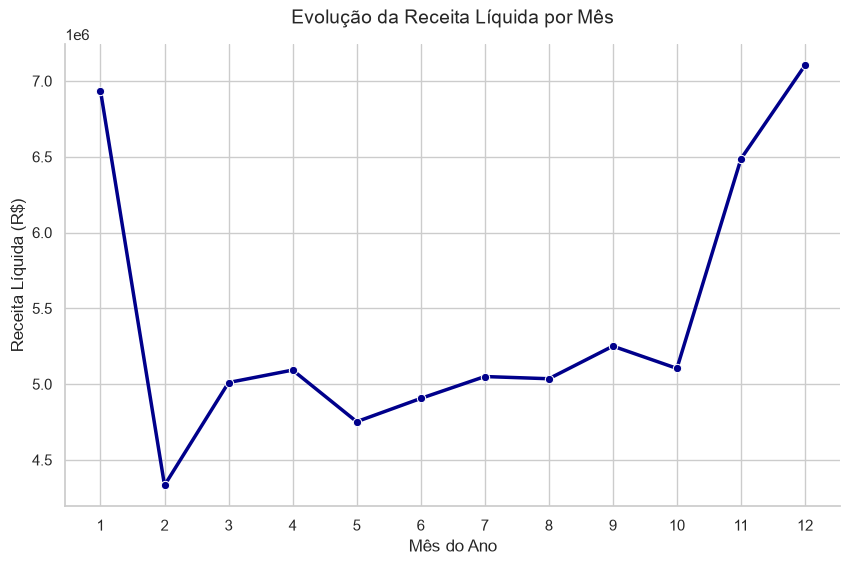

In [19]:
plt.figure(figsize=(10, 6))
receita_mes = df.groupby('mes')['receita_liquida'].sum().reset_index()
sns.lineplot(data=receita_mes, x='mes', y='receita_liquida', marker='o', linewidth=2.5, color='darkblue')
plt.title('Evolução da Receita Líquida por Mês', fontsize=14, pad=15)
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Receita Líquida (R$)', fontsize=12)
plt.xticks(range(1, 13))
sns.despine()
plt.show()

a linha do tempo mostra como a receita variou mês a mês, com isso, conseguimos visualizar os picos de faturamento e as épocas de queda, o que é ótimo para entender a sazonalidade do negócio.

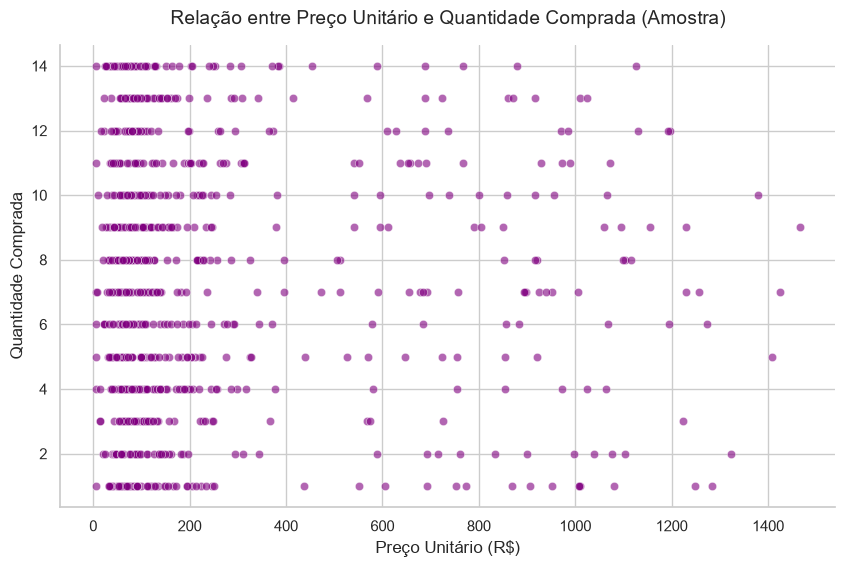

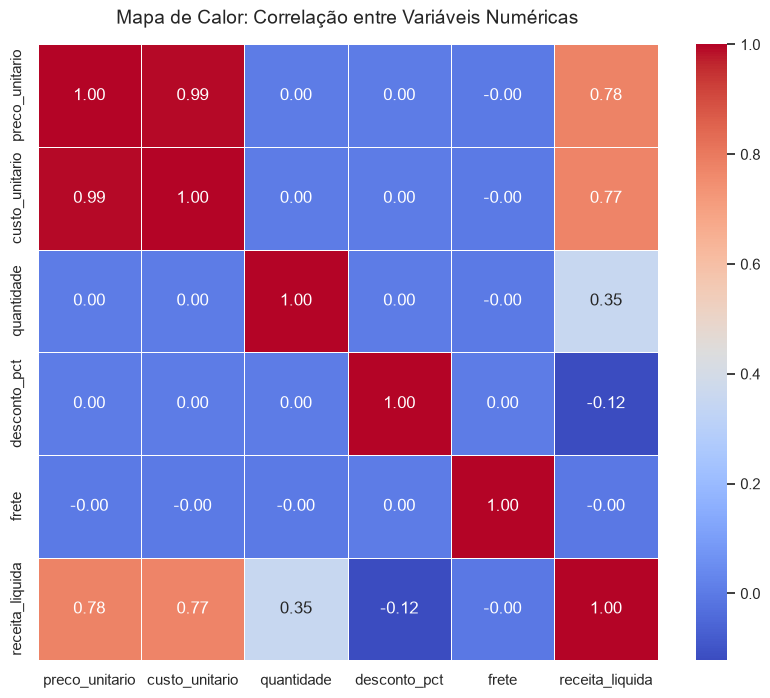

In [20]:
plt.figure(figsize=(10, 6))
amostra_df = df.sample(n=800, random_state=42)
sns.scatterplot(data=amostra_df, x='preco_unitario', y='quantidade', alpha=0.6, color='purple')
plt.title('Relação entre Preço Unitário e Quantidade Comprada (Amostra)', fontsize=14, pad=15)
plt.xlabel('Preço Unitário (R$)', fontsize=12)
plt.ylabel('Quantidade Comprada', fontsize=12)
sns.despine()
plt.show()
print("\n" + "="*50 + "\n")
plt.figure(figsize=(10, 8))
colunas_num = ['preco_unitario', 'custo_unitario', 'quantidade', 'desconto_pct', 'frete', 'receita_liquida']
correlacao = df[colunas_num].corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlação entre Variáveis Numéricas', fontsize=14, pad=15)
plt.show()

Gráfico de Dispersão:
Os pontos espalhados mostram a relação entre o preço do produto e quantas unidades o cliente levou.

Mapa de Calor:
O mapa mostra como os números da empresa interagem. O vermelho forte (valor 1.0) entre preço Unitário e custo Unitário confirma uma correlação alta, ou seja, produtos mais caros para o cliente também custam mais caro para a empresa comprar do fornecedor.

Conclusão Final do Projeto
Analisando toda a base de dados, fica claro que a saúde financeira da operação depende muito da categoria de eletrônicos. Também é possível identificar a sazonalidade forte nas vendas ao longo dos meses. Como ponto de atenção para a gestão, o alto número de devoluções e a quantidade de vendas gerando prejuízo precisam ser acompanhados de perto para otimizar os resultados futuros da empresa.